# PRUEBA DEL TFT CON DATOS REALES:

Este notebook es dependiente de cuda y pytorch, junto con otras librerias derivadas. Recomendado el uso del docker correspondiente para su GPU.

En este notebook se llevara a cabo una función que transforme los datos limpios a un formato predecible y entrenaremos un pseudomodelo con el TFT the pytorch forecasting

## ¿Por qué volvemos al TFT?:

Viendo el intento de usar Tide y nhits(este último no tiene notebook), vemos que no saben manejar grupos con distribuciones tan diferentes, viendo esto no nos queda más opción que volver al TFT. Para mejorar el rendimiento y los rtesultados solo predeciremos de momento demanda para asegurar un buen entrenamiento,además de plantear algunas transformaciones útiles

In [ ]:
import torch
import gc

def liberar_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        print("Caché de GPU liberado.")
    else:
        print("GPU no detectada o no disponible.")

# Ejecutar la limpieza
liberar_gpu()

Caché de GPU liberado.


In [ ]:
# Librerias necesarias muchas de ellas no se utilizan ya que han habido varios intentos de código, pero las dejo por si acaso
import polars as pl
import numpy as np
from pytorch_forecasting import TimeSeriesDataSet, GroupNormalizer,MultiNormalizer
import lightning.pytorch as pl_train  # Para el entrenamiento (le pongo alias diferente para evitar confusión)
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting.metrics import MultiLoss, QuantileLoss
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import MAE
import matplotlib.pyplot as plt
import torch


## 1. Preprocesamiento de los datos

Importamos los datos

In [1]:
import sys
from pathlib import Path

root = Path.cwd().parent 
sys.path.append(str(root))

from minio_utils.minio_script import MinioPD2

path = Path.cwd()
if not Path(path, "data").exists(): path = path.parent
path_data = path / "data" / "january.parquet"
minio = MinioPD2()
minio.download_file(path / "data", file_name=path_data.name)

minio.fdi.ucm.es l9fhIzbW1jIr7aycz2Ut zfKblcB2smbqjslYkBXwHK06SfIpSkmlPIf74hFv
Object(bucket_name='pd2', object_name='cityenjoyer/january.parquet', last_modified=datetime.datetime(2026, 2, 15, 12, 12, 39, 629000, tzinfo=datetime.timezone.utc), etag='dc24cfb502c270a7455e9e1d9acf7f54', size=400741492, metadata={}, version_id=None, is_latest=None, storage_class='STANDARD', owner_id='02d6176db174dc93cb1b899f7c6078f08654445fe8cf1b6ce98d8855f66bdbf4', owner_name='minio', content_type=None, is_delete_marker=False, tags=None, is_dir=False)
Encontrado archivo local: /home/danpanto/Desktop/C-ity-enjoyers/data/january.parquet


In [ ]:
lf = pl.scan_parquet(path_data)
#Las variables estaticas son str ya que pytorch es muy restrictivo con su tipado
#y no deja que un entero represente una variable categórica


Para utilizar el tft debemos poder predecir algo, en nuestro caso predeciremos la media y std del precio además de la demanda total por zona y servicio. Para ello debemos transformar el dataset

In [ ]:
def prepare_tft_dataset(lf: pl.LazyFrame):
    # 1. Truncar a 30 minutos y Agrupar
    tft_df = (
        lf.filter(pl.col("total_amount") > 0) 
        .with_columns([
            pl.col("pickup_datetime").dt.truncate("30m").alias("pickup_interval")
        ])
        .group_by(["VendorID", "PULocationID", "pickup_interval"])
        .agg([
            pl.len().alias("demanda"),
            pl.col("total_amount").mean().alias("precio_medio"),
            pl.col("total_amount").std().alias("precio_std"),
            pl.col("trip_distance").mean().alias("distancia_media")
        ])
        .collect()
    )

    # 2. Upsampling
    tft_df = (
        tft_df.sort("pickup_interval")
        .upsample(
            time_column="pickup_interval",
            every="30m",
            group_by=["VendorID", "PULocationID"]
        )
        .with_columns([
            pl.col("demanda").fill_null(0).cast(pl.Float32),
            pl.col("precio_medio").forward_fill().over(["VendorID", "PULocationID"]).fill_null(0).cast(pl.Float32),
            pl.col("precio_std").fill_null(0).cast(pl.Float32),
            pl.col("distancia_media").forward_fill().over(["VendorID", "PULocationID"]).fill_null(0).cast(pl.Float32)
        ])
    )

    # 3. Transformación Cíclica
    min_date = tft_df["pickup_interval"].min()
    
    tft_df = tft_df.with_columns([
        ((pl.col("pickup_interval") - min_date).dt.total_seconds() / 1800).cast(pl.Int32).alias("time_idx"),
        pl.col("VendorID").cast(pl.String),
        pl.col("PULocationID").cast(pl.String),
        (pl.col("pickup_interval").dt.hour() + (pl.col("pickup_interval").dt.minute() / 60.0)).alias("_tmp_hour"),
        (pl.col("pickup_interval").dt.weekday()).alias("_tmp_day")
    ]).with_columns([
        (pl.col("_tmp_hour") * (2 * np.pi / 24)).sin().cast(pl.Float32).alias("hour_sin"),
        (pl.col("_tmp_hour") * (2 * np.pi / 24)).cos().cast(pl.Float32).alias("hour_cos"),
        (pl.col("_tmp_day") * (2 * np.pi / 7)).sin().cast(pl.Float32).alias("day_sin"),
        (pl.col("_tmp_day") * (2 * np.pi / 7)).cos().cast(pl.Float32).alias("day_cos")
    ]).drop(["_tmp_hour", "_tmp_day"])

    # 4. LIMPIEZA DE INFINITOS y NAN
    cols_to_clean = ["precio_medio", "precio_std", "distancia_media"]
    
    tft_df = tft_df.with_columns([
        pl.when(pl.col(c).is_infinite() | pl.col(c).is_nan())
        .then(0)
        .otherwise(pl.col(c))
        .alias(c) 
        for c in cols_to_clean
    ])

    return tft_df

In [5]:
df = prepare_tft_dataset(lf)
df

VendorID,PULocationID,pickup_interval,demanda,precio_medio,precio_std,distancia_media,time_idx,hour_sin,hour_cos,day_sin,day_cos
str,str,datetime[μs],f32,f32,f32,f32,i32,f32,f32,f32,f32
"""1""","""88""",2025-01-01 00:00:00,9.0,34.298889,16.199581,4.96,290,0.0,1.0,0.433884,-0.900969
"""1""","""88""",2025-01-01 00:30:00,20.0,27.077999,15.40177,4.9825,291,0.130526,0.991445,0.433884,-0.900969
"""1""","""88""",2025-01-01 01:00:00,20.0,35.473999,15.684196,5.0155,292,0.258819,0.965926,0.433884,-0.900969
"""1""","""88""",2025-01-01 01:30:00,17.0,34.821175,7.99483,5.052941,293,0.382683,0.92388,0.433884,-0.900969
"""1""","""88""",2025-01-01 02:00:00,18.0,29.708889,9.30876,4.589445,294,0.5,0.866025,0.433884,-0.900969
…,…,…,…,…,…,…,…,…,…,…,…
"""1""","""26""",2025-01-31 20:30:00,0.0,30.790001,0.0,0.0,1771,-0.793353,0.608761,-0.974928,-0.222521
"""1""","""26""",2025-01-31 21:00:00,0.0,30.790001,0.0,0.0,1772,-0.707107,0.707107,-0.974928,-0.222521
"""1""","""26""",2025-01-31 21:30:00,0.0,30.790001,0.0,0.0,1773,-0.608761,0.793353,-0.974928,-0.222521


Una vez tenemos el dataset ya en un formato entrenable creamos un timeseries dataset de pytorch_forecasting y lo dividimos en train y test

In [6]:
df = df.to_pandas() #para usar pytorch necesitamos pandas inicialmente

In [ ]:
# 1. Definir horizonte y contexto
max_prediction_length = 24  # 12 horas (si tus intervalos son de 30 min)
max_encoder_length = 48    # 2 dias de contexto (48 intervalos por día)

# 2. Punto de corte para validación (ej. los últimos 2 días)
training_cutoff = df["time_idx"].max() - max_prediction_length

# 3. Dataset de Entrenamiento
training = TimeSeriesDataSet(
    df[df["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="demanda",
    group_ids=["VendorID", "PULocationID"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["VendorID", "PULocationID"],
    time_varying_known_reals=[
        "time_idx", "hour_sin", "hour_cos", "day_sin", "day_cos"
    ],
    time_varying_unknown_reals=[
        "demanda", "precio_medio", "precio_std", "distancia_media"
    ],
    target_normalizer=GroupNormalizer(groups=["VendorID", "PULocationID"], transformation="softplus"),  # Normalización específica por serie
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# 4. Dataset de Validación
# Usamos predict=True para que solo tome el último fragmento de cada serie para validar
validation = TimeSeriesDataSet.from_dataset(
    training, 
    df, 
    predict=True, 
    stop_randomization=True
)

# Definimos el tamaño del lote (Batch Size)
batch_size = 1024

# Crear Dataloader de Entrenamiento
train_dataloader = training.to_dataloader(
    train=True, 
    batch_size=batch_size, 
    num_workers=8,              # Paralelizamos los cálculos
    shuffle=True,               # Mezclamos los índices de las series, no el tiempo
    drop_last=True              # Evita que el último batch pequeño desestabilice el gradiente
)

# Crear Dataloader de Validación
# IMPORTANTE: En validación NO se hace shuffle para poder visualizar series coherentes
val_dataloader = validation.to_dataloader(
    train=False, 
    batch_size=batch_size * 4,  # Puede ser mayor porque no calcula gradientes (más rápido)
    num_workers=8, 
    shuffle=False, 
    drop_last=False
)

/usr/local/lib/python3.12/dist-packages/pytorch_forecasting/data/timeseries/_timeseries.py:1859: UserWarning: Min encoder length and/or min_prediction_idx and/or min prediction length and/or lags are too large for 30 series/groups which therefore are not present in the dataset index. This means no predictions can be made for those series. First 10 removed groups: [{'__group_id__VendorID': '0', '__group_id__PULocationID': '100'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '125'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '128'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '141'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '142'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '143'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '170'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '175'}, {'__group_id__VendorID': '0', '__group_id__PULocationID': '178'}, {'__group_id__VendorID': '0', '__group_

Una vez tenemos ya todo listo solo queda entrenar el tft

(5 épocas ha tardado una hora)

In [9]:
# 1. Configurar la arquitectura del TFT
# Nota: Como es Multi-Target, usamos MultiLoss con 3 QuantileLoss
# Configuración "Bestia" para velocidad máxima
from pytorch_forecasting.metrics import MultiLoss, RMSE
model = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.01,
    hidden_size=128,            # <--- RELEVANTE: 32 es suficiente para empezar en CPU
    lstm_layers=1,   
    attention_head_size=1,     # <--- RELEVANTE: Menos cabezas = más velocidad en CPU
    dropout=0.1,
    loss=QuantileLoss(),               # Cambia a RMSE para evitar líos de dimensiones por ahora
    reduce_on_plateau_patience=4
)
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor

# 2. Configuración del Trainer "Modo Carrera"
trainer = pl_train.Trainer(
    max_epochs=5,
    accelerator="gpu",
    devices=1,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=3),
        LearningRateMonitor(logging_interval="step")
    ],
    # Si quieres que vaya aún más rápido sacrificando logs
    enable_checkpointing=True,
    logger=True
)

# ¡A correr!
trainer.fit(
    model,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which 

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  9.5 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    208 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 10.5 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 33.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 19.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  132 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  132 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 65.9 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    903 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 918 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 918 K                                                                                                
Total estimated model params size (MB): 3                                                                          
Modules in train mode: 444                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

`Trainer.fit` stopped: `max_epochs=5` reached.


Comprobemos los resultados:

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


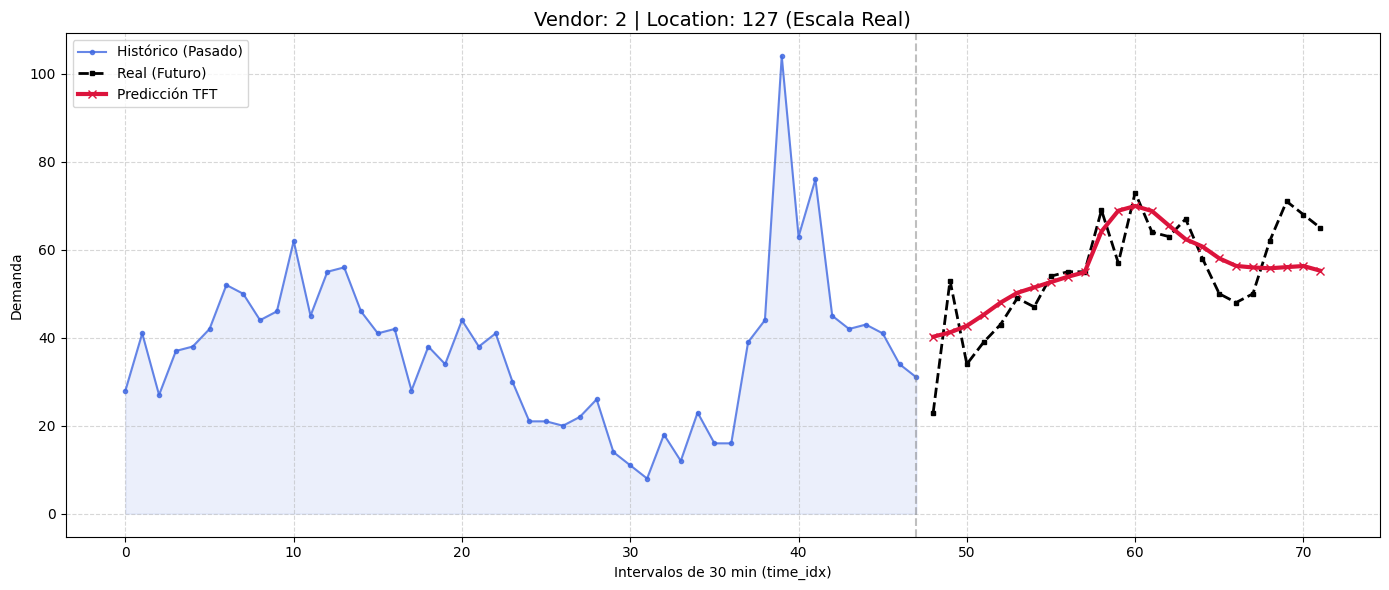

In [ ]:

def plot_full_prediction(preds_output, training_dataset, vendor_id, location_id):
    # preds_output es una NamedTuple: (output, x)
    predictions = preds_output.output
    x_metadata = preds_output.x
    
    # 1. Encontrar el índice de la serie
    group_ids = training_dataset.x_to_index(x_metadata)
    target_mask = (group_ids["VendorID"] == vendor_id) & (group_ids["PULocationID"] == location_id)
    target_idx = group_ids[target_mask].index
    
    if len(target_idx) == 0:
        print(f"Sin datos para Vendor {vendor_id}, Location {location_id}")
        return
    
    idx = target_idx[0]
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # 2. Extraer datos (manejo de tensores)
    # Encoder target: [Batch, Time] -> Escala REAL gracias al inverse transform de predict()
    past_real = x_metadata["encoder_target"][idx].cpu().numpy()
    future_real = x_metadata["decoder_target"][idx].cpu().numpy()
    
    # 3. Manejo de predicciones (Quantiles)
    # Si usaste QuantileLoss, 'predictions' puede tener forma [Batch, Time, Quantiles]
    # mode="prediction" devuelve el cuantil 0.5 por defecto.
    if predictions.ndim == 3:
        # Si por alguna razón recibes todos los cuantiles, tomamos el medio (índice 3 de 7)
        future_pred = predictions[idx, :, predictions.shape[-1] // 2].cpu().numpy()
    else:
        future_pred = predictions[idx].cpu().numpy()
    
    # 4. Ejes X
    x_past = np.arange(len(past_real))
    x_future = np.arange(len(past_real), len(past_real) + len(future_real))
    
    # 5. Dibujar
    ax.plot(x_past, past_real, label="Histórico (Pasado)", color="royalblue", alpha=0.8, marker='o', markersize=3)
    ax.plot(x_future, future_real, label="Real (Futuro)", color="black", lw=2, linestyle="--", marker='s', markersize=3)
    ax.plot(x_future, future_pred, label="Predicción TFT", color="crimson", lw=3, marker='x')
    
    # Línea divisoria entre pasado y futuro
    ax.axvline(x=len(past_real)-1, color='gray', linestyle='--', alpha=0.5)
    ax.fill_between(x_past, 0, past_real, color="royalblue", alpha=0.1)
    
    ax.set_title(f"Vendor: {vendor_id} | Location: {location_id} (Escala Real)", fontsize=14)
    ax.set_ylabel("Demanda")
    ax.set_xlabel("Intervalos de 30 min (time_idx)")
    ax.legend(loc="upper left")
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# --- EJECUCIÓN ---
model.eval()

# Es mejor usar mode="prediction" para que la salida sea un tensor directo 
# y no la distribución cruda de cuantiles si solo quieres la línea.
preds = model.predict(
    val_dataloader, 
    mode="prediction", 
    return_x=True
)

plot_full_prediction(preds, training, vendor_id="2", location_id="127")

Vemos que los resultados son mucho mejores que los primeros, obteniendo unos resultados muy remarcables para solo 4 épocas